In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
from math import comb

In [ ]:
# Creating Proability Mass Function (PMF) by hand, use for calculating PMF for binonimal theorem.

def my_binomial_pmf(k, n, s):
    # s = sucess-rate
    # n = number of data points
    # k = true|positive data points
    return comb(n, k) * s**k * (1-s)**(n-k)

print(f"my binomial distribution: {my_binomial_pmf(k=48, n=50, s=0.95).__round__(4)}")

print(f"scipy binomial distribution: {scipy.stats.binom.pmf(48, 50, 0.95).__round__(4)}")

my binomial distribution: 0.2611
scipy binomial distribution: 0.2611


In [ ]:
# Proability means likelyhood
# proability = 0% means event is impossible to occure.
# proability = 0.5% means event has equal chances to occure.
print("A coin is fair. What is the probability of exactly 7 heads in 10 flips? ",my_binomial_pmf(7, 10, 0.5).__round__(2))

 
print("\nA seller has a 95% success rate. What is the probability of a perfect 10 out of 10? ",my_binomial_pmf(10, 10, 0.95).__round__(2))
 
k_range = np.arange(0, 9, 1)
print("\nSame seller. What is the probability of 8 or fewer out of 10? ",sum([my_binomial_pmf(k, 10, 0.95) for k in k_range]).__round__(2))

# here success doesn't mean a positive event, it means the given event. for below case its the defect rate.
print("\nA factory has a 2% defect rate. In 100 cars, what is the probability of exactly 0 defects? ",my_binomial_pmf(0, 100, 0.02).__round__(2))

k_range = np.arange(5, 100, 1)
print("\nSame factory. What is the probability of 5 or more defects in 100? ",sum([my_binomial_pmf(k, 100, 0.02) for k in k_range]).round(2))

A coin is fair. What is the probability of exactly 7 heads in 10 flips?  0.12

A seller has a 95% success rate. What is the probability of a perfect 10 out of 10?  0.6

Same seller. What is the probability of 8 or fewer out of 10?  0.09

A factory has a 2% defect rate. In 100 cars, what is the probability of exactly 0 defects?  0.13

Same factory. What is the probability of 5 or more defects in 100?  0.05


*For the question no 1 and 3 we sum multiple answers together to get a cumulative result. This is called CDF (Cumulative distribution function)*

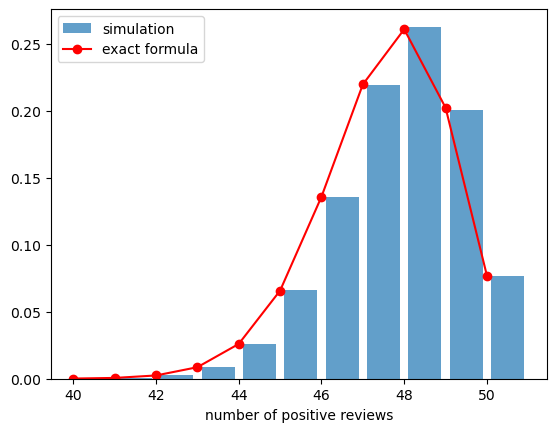

In [133]:
n, s = 50, 0.95

samples = np.random.binomial(n, s, size=100000) # we take the binominal disritution of 100,000 samples for which each sample has 50 data point, with sucess_rate = 95%

plt.hist(samples, bins=range(40,52), density=True, alpha=0.7, label='simulation', rwidth=0.8)

# overlay the exact formula
k = np.arange(40, 51)
plt.plot(k, scipy.stats.binom.pmf(k, n, s), 'o-', color='red', label='exact formula')

plt.legend()
plt.xlabel('number of positive reviews')
plt.show()

In [ ]:
# checking the result of 95% sucess-rate on the sample of 50 random numbers.

samples_n = np.random.rand(50,1)
success_rate = 0.95
final_n = [ 1 if i> 0.95 else 0 for i in samples_n]
np.unique_counts(final_n)

UniqueCountsResult(values=array([0, 1]), counts=array([47,  3]))

In [126]:
def plot_binomial_theorem(n, s, k, bins_range):
    samples = np.random.binomial(n, s, size=100000) # we take the binominal disritution of 100,000 samples for which each sample has 50 data point, with sucess_rate = 95%
    plt.hist(samples, bins=bins_range, density=True, alpha=0.7, label='simulation', rwidth=0.8)

    # overlay the exact formula
    # k = np.arange(40, 51)
    plt.plot(k, scipy.stats.binom.pmf(k, n, s), 'o-', color='red', label='exact formula')

    plt.legend()
    plt.xlabel('number of positive reviews')
    plt.show()

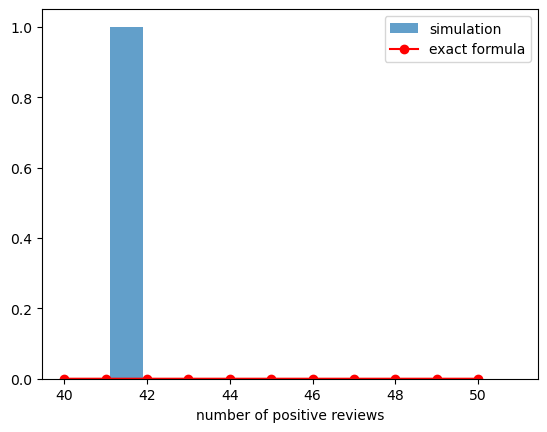

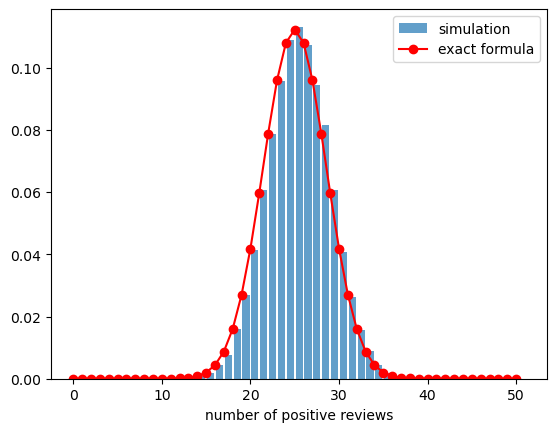

In [138]:
# What happens to the graph shape when s = 0.5 instead of 0.95?

plot_binomial_theorem(n=50, s=0.5, k=np.arange(40, 51), bins_range=range(40,52)) # This happened because most of the values lies around 25.

# as you can see below
plot_binomial_theorem(n=50, s=0.5, k=np.arange(0, 51), bins_range=range(0,52)) 

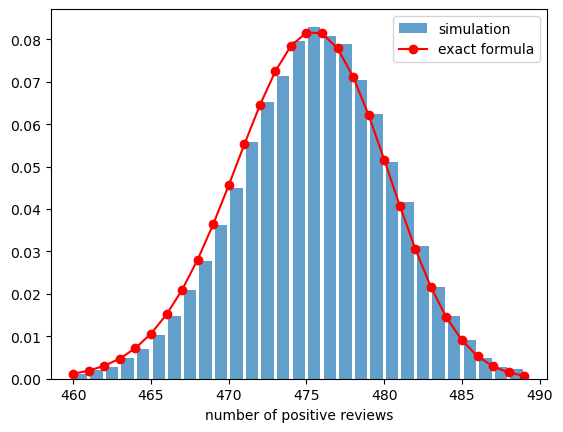

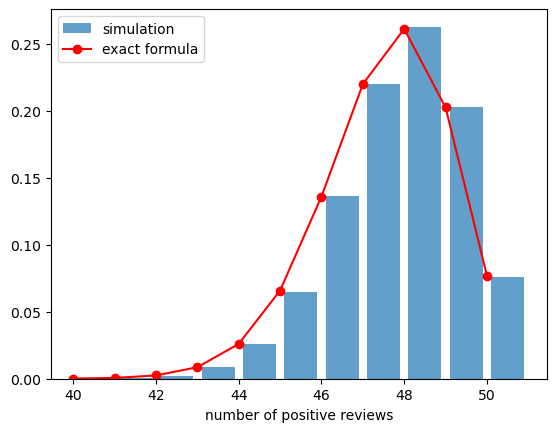

In [151]:
# What happens when n grows from 50 to 500?

plot_binomial_theorem(n=500, s=0.95, k=np.arange(460, 490), bins_range=range(460,490)) # as now the range falls around 475 

plot_binomial_theorem(n=50, s=0.95, k=np.arange(40, 51), bins_range=range(40,52)) 

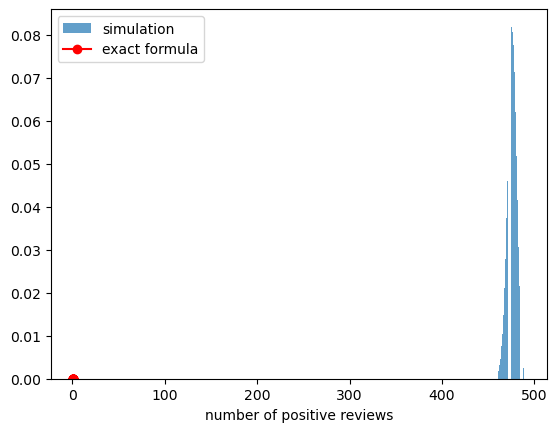

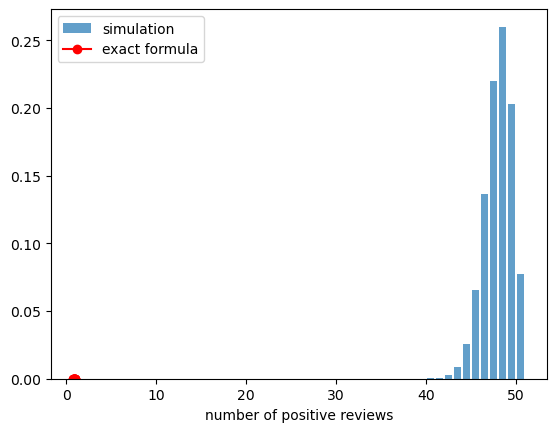

In [158]:
# What happens to the spread as n increases?

n=500
plot_binomial_theorem(n=n, s=0.95, k=np.arange(460, 490)/n, bins_range=range(460,490)) # as now the range falls around 475 

n=50
plot_binomial_theorem(n=n, s=0.95, k=np.arange(40, 51)/n, bins_range=range(40,52)) 

# Conclustion:

# With the increase in speard the spead will get squished with respect to n. As you can see here.

In [163]:
### here is a mathmetical view of how and why this is happening.

# when n was 50 the spread was around 40 to 50
n = 50
spread = 50-40 # 10 times
print("spread with n = 50: ", (spread/n)*100, "% of the range")

# when n was about 500 speard was around 460 to 490
n=500
spread=490-460
print("spread with n = 500: ", (spread/n)*100, "% of the range")

spread with n = 50:  20.0 % of the range
spread with n = 500:  6.0 % of the range
